In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.express as px
import os




print(os.getcwd())

c:\Users\HP\OneDrive\Desktop\bluestock_mf_capstone\notebook


In [2]:
# NAV Trend Analysis

nav_history = pd.read_csv("../data/processed/nav_history_clean.csv")

nav_history["date"] = pd.to_datetime(nav_history["date"])

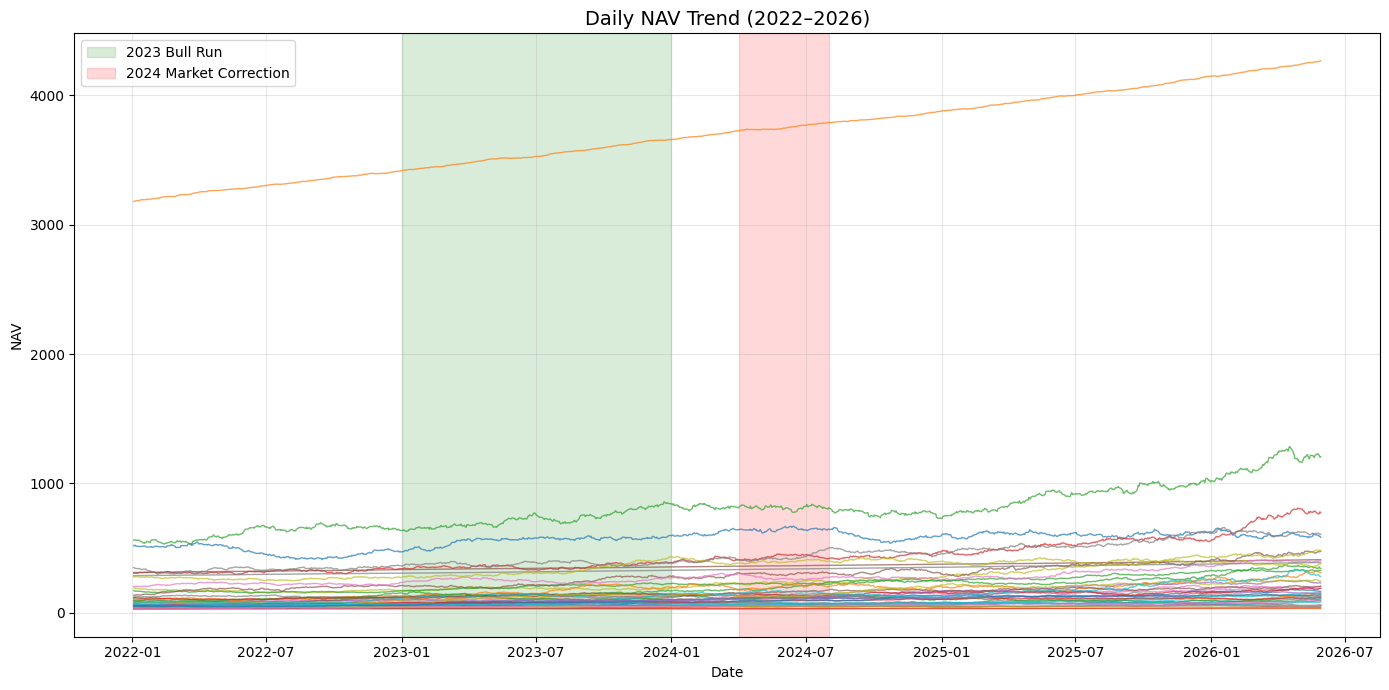

In [3]:


# Create figure
plt.figure(figsize=(14, 7))

# Plot NAV trends for all schemes
for scheme in nav_history["amfi_code"].unique():
    data = nav_history[nav_history["amfi_code"] == scheme]

    plt.plot(
        data["date"],
        data["nav"],
        linewidth=1,
        alpha=0.7
    )

# Highlight 2023 Bull Run
plt.axvspan(
    pd.to_datetime("2023-01-01"),
    pd.to_datetime("2023-12-31"),
    color="green",
    alpha=0.15,
    label="2023 Bull Run"
)

# Highlight 2024 Market Correction
plt.axvspan(
    pd.to_datetime("2024-04-01"),
    pd.to_datetime("2024-08-01"),
    color="red",
    alpha=0.15,
    label="2024 Market Correction"
)

plt.title("Daily NAV Trend (2022–2026)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



In [4]:
# AUM Growth Bar Chart
import pandas as pd
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [5]:
aum["date"] = pd.to_datetime(aum["date"])


In [6]:

aum["year"] = aum["date"].dt.year

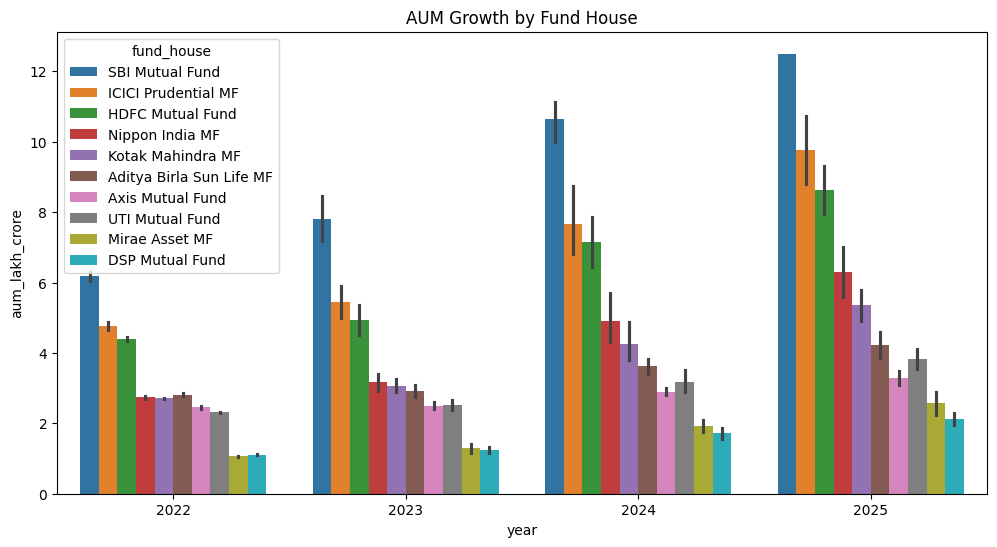

In [7]:
# AUM Growth Bar Chart

plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")
plt.show()



In [8]:
monthly_sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")


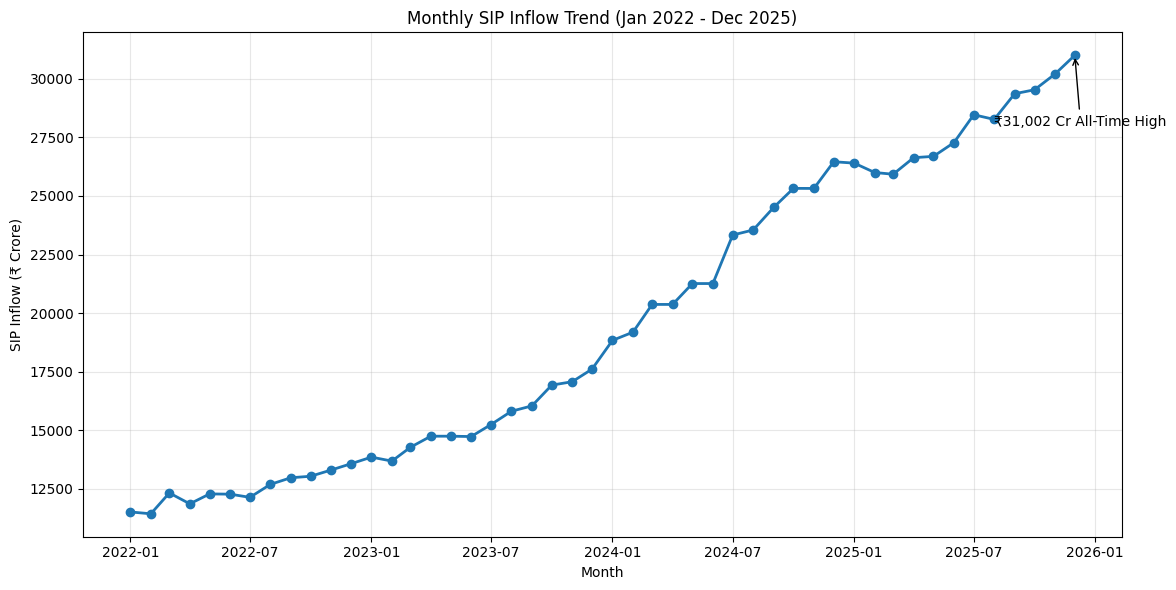

In [9]:
# SIP Inflow Trend

monthly_sip["month"] = pd.to_datetime(monthly_sip["month"])

plt.figure(figsize=(12, 6))

# Line plot with markers
plt.plot(
    monthly_sip["month"],
    monthly_sip["sip_inflow_crore"],
    marker="o",
    linewidth=2
)

# Annotate all-time high
plt.annotate(
    "₹31,002 Cr All-Time High",
    xy=(pd.Timestamp("2025-12-01"), 31002),
    xytext=(pd.Timestamp("2025-08-01"), 28000),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

plt.title("Monthly SIP Inflow Trend (Jan 2022 - Dec 2025)")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (₹ Crore)")

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()



In [10]:
# Category inflow heatmap

category_inflows = pd.read_csv("../data/raw/05_category_inflows.csv")

category_inflows.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [11]:
pivot_table = category_inflows.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

pivot_table.head()

month,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


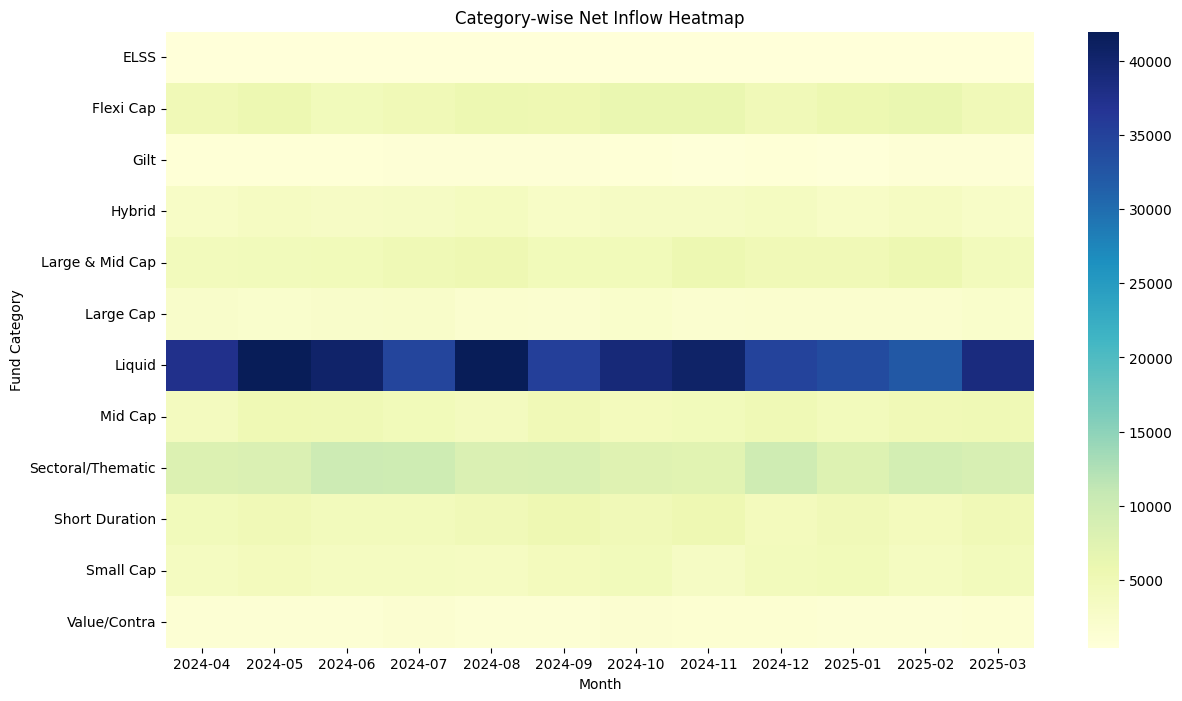

In [12]:
# Category inflow heatmap

plt.figure(figsize=(14,8))
sns.heatmap(
    pivot_table,
    cmap="YlGnBu",
    annot=False
)

plt.title("Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.show()

In [13]:
import pandas as pd

investor_transactions = pd.read_csv("../data/processed/investor_transactions_clean.csv")

investor_transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [14]:
investor_transactions.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')

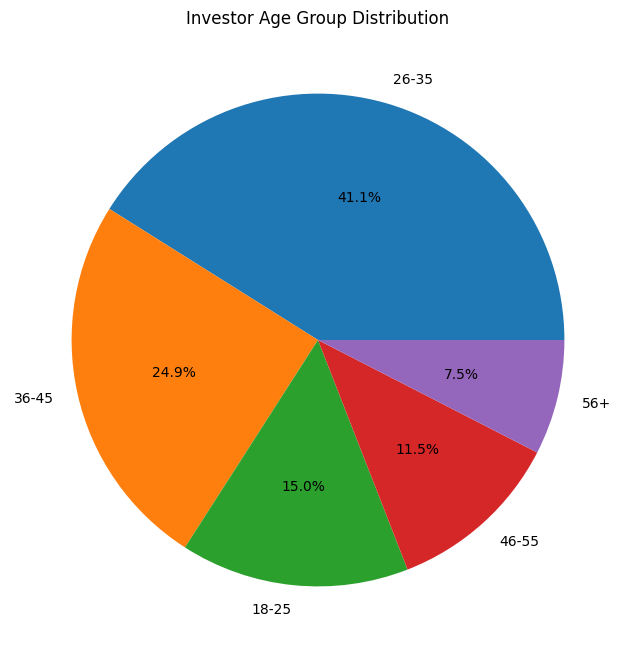

In [15]:
# . Age Group Distribution Pie Chart

age_counts = investor_transactions["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(age_counts,labels=age_counts.index,autopct="%1.1f%%")

plt.title("Investor Age Group Distribution")

plt.show()

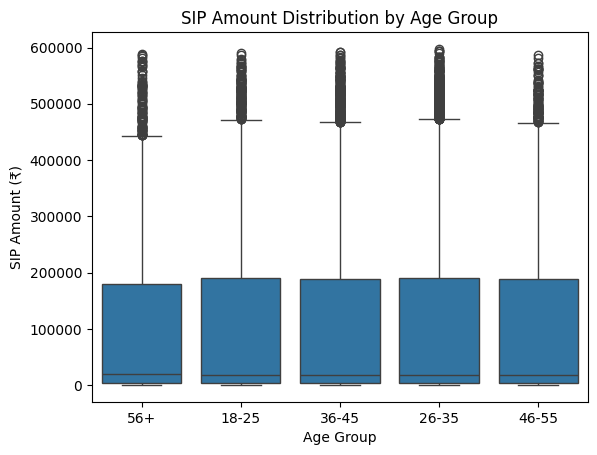

In [16]:
# SIP Amount Box Plot by Age Group

sns.boxplot(data=investor_transactions,
    x="age_group",y="amount_inr")

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("SIP Amount (₹)")

plt.show()

In [17]:
# Note: The box plot shows the distribution of SIP amounts across different age groups. 
# The median SIP amount is highest for the 35-44 age group, indicating that investors in this age range tend to invest more in SIPs compared to other age groups. 
# The 25-34 age group also shows a relatively high median SIP amount, while the 18-24 and 45-54 age groups have lower median SIP amounts. 
# The presence of outliers in the 35-44 and 25-34 age groups suggests that there are some investors who invest significantly higher amounts in SIPs.

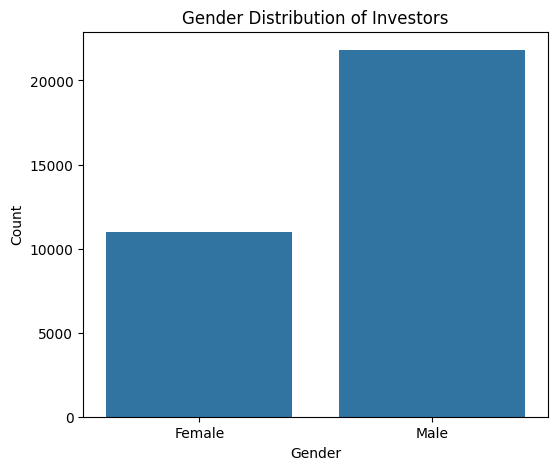

In [18]:
# Gender split

plt.figure(figsize=(6,5))

sns.countplot(data=investor_transactions,x="gender")

plt.title("Gender Distribution of Investors")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

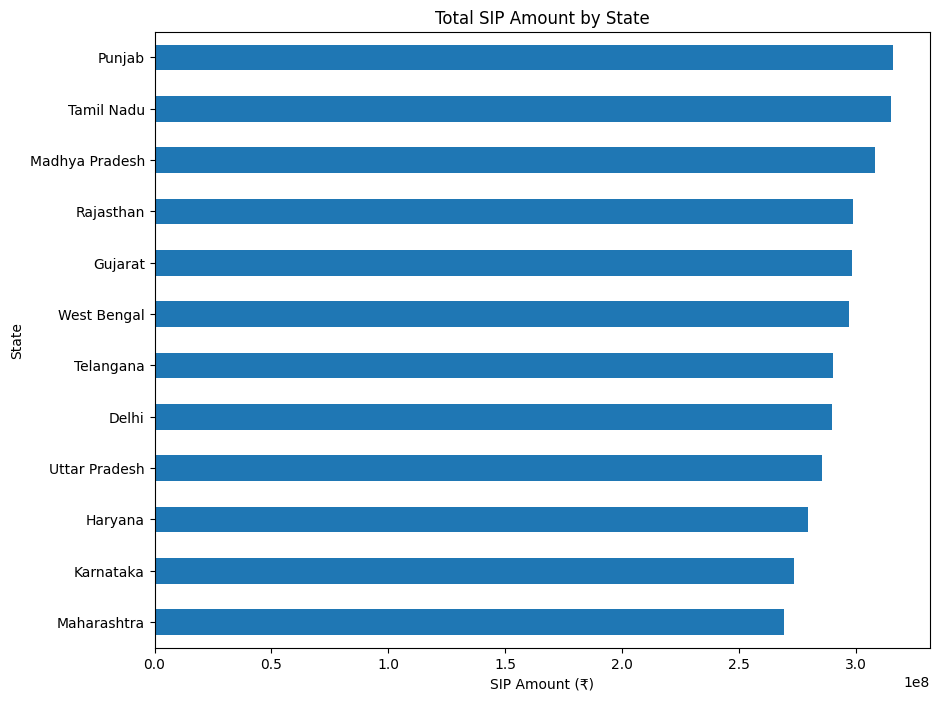

In [19]:
# SIP Amount by State

state_sip = (
    investor_transactions.groupby("state")["amount_inr"].sum().sort_values())
plt.figure(figsize=(10,8))

state_sip.plot(kind="barh")

plt.title("Total SIP Amount by State")
plt.xlabel("SIP Amount (₹)")
plt.ylabel("State")

plt.show()

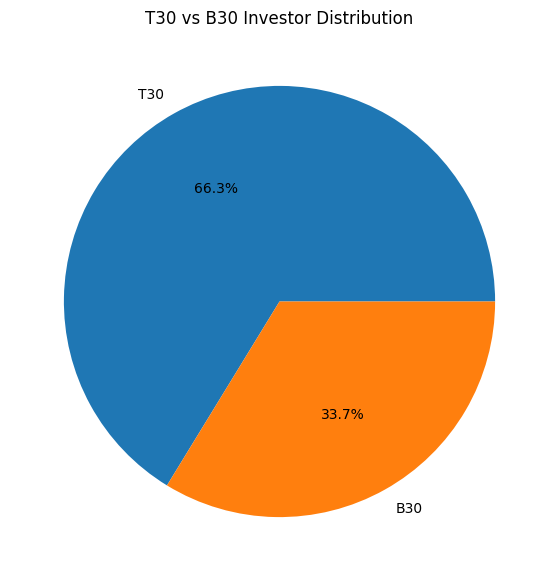

In [20]:
# T30 vs B30 city tier pie chart.

tier_counts = investor_transactions["city_tier"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Investor Distribution")

plt.show()

In [21]:
# NOTE: 63% ofinvestors are from T30 cities,while 33% are from B30 cities.

In [22]:
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

folio.columns

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='object')

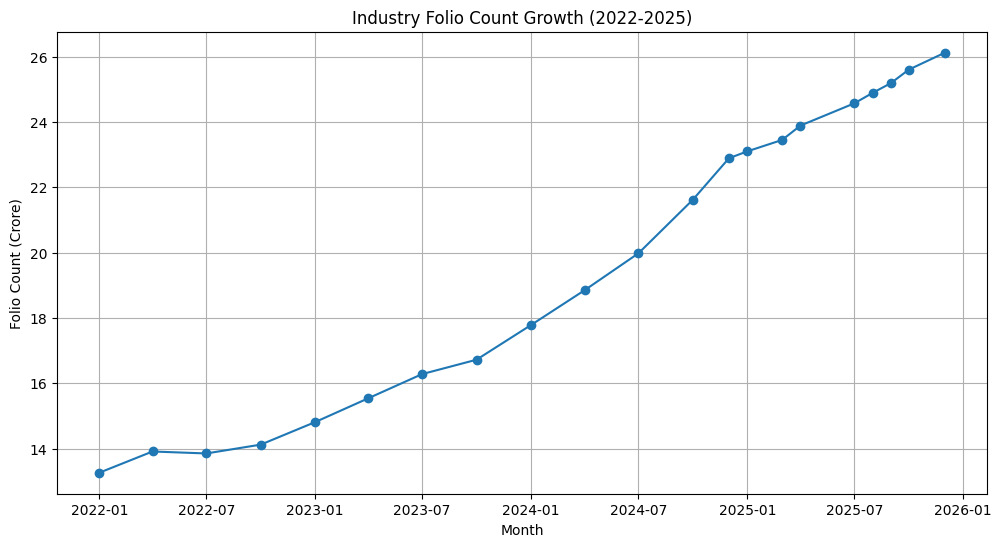

In [23]:
# Folio count growth line chart

folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(12,6))

plt.plot(folio["month"],folio["total_folios_crore"],marker="o")

plt.title("Industry Folio Count Growth (2022-2025)")
plt.xlabel("Month")
plt.ylabel("Folio Count (Crore)")

plt.grid(True)

plt.show()

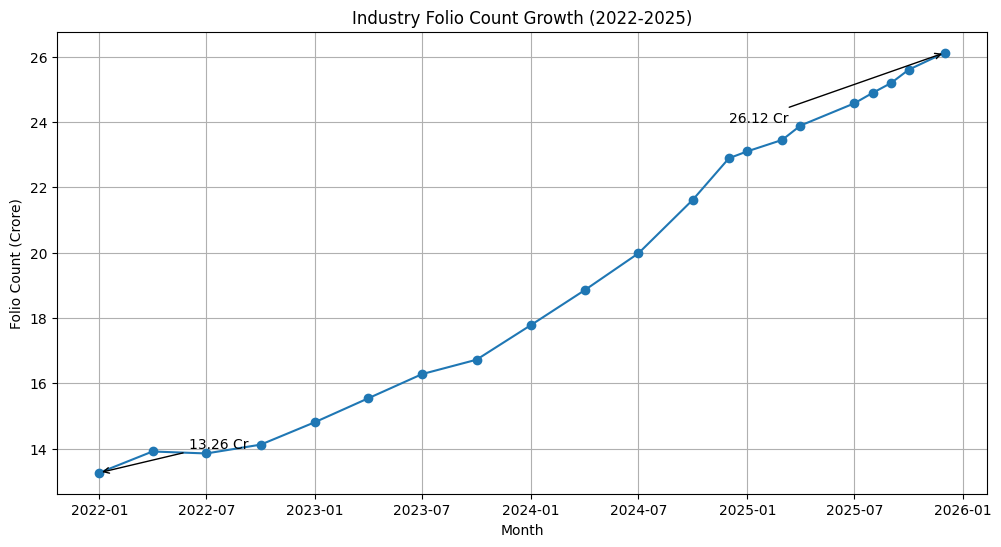

In [24]:
# Mark Key Milestones

plt.figure(figsize=(12,6))

plt.plot(folio["month"],folio["total_folios_crore"],marker="o")

plt.annotate("13.26 Cr",
    xy=(pd.Timestamp("2022-01-01"), 13.26),
    xytext=(pd.Timestamp("2022-06-01"), 14),
    arrowprops=dict(arrowstyle="->"))

plt.annotate("26.12 Cr",
    xy=(pd.Timestamp("2025-12-01"), 26.12),
    xytext=(pd.Timestamp("2024-12-01"), 24),
    arrowprops=dict(arrowstyle="->"))

plt.title("Industry Folio Count Growth (2022-2025)")
plt.xlabel("Month")
plt.ylabel("Folio Count (Crore)")

plt.grid(True)

plt.show()

<!-- Industry folio count nearly doubled from 13.26 crore in January 2022 to 26.12 crore in December 2025, indicating strong growth in mutual fund investor participation and account penetration. -->

In [25]:
# Checking of  NAV Data

nav_history["date"] = pd.to_datetime(nav_history["date"])

selected_funds = (nav_history["amfi_code"].unique()[:10])

selected_funds

array([100016, 100025, 100033, 101206, 101207, 101208, 102885, 102886,
       102887, 118632])

In [26]:
nav_10 = nav_history[
    nav_history["amfi_code"]
    .isin(selected_funds)
]

In [27]:
nav_pivot = nav_10.pivot(
    index="date",
    columns="amfi_code",
    values="nav")

nav_pivot.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
date,,,,,,,,,,
2022-01-03,520.4608,26.3169,107.3758,305.0996,38.5736,310.7415,89.8728,119.2905,191.0721,42.8339
2022-01-04,515.0971,26.2234,105.9447,305.4514,38.1545,310.6977,90.8724,120.6402,189.0737,42.8033
2022-01-05,521.7239,26.2221,105.4800,306.6324,38.1775,310.8165,90.1565,121.4580,188.0701,43.0564
2022-01-06,515.7880,26.1728,104.9350,305.9800,37.0665,310.7719,91.5338,125.2386,190.4545,43.2088
2022-01-07,515.1639,26.2261,104.3318,304.0480,37.9845,310.8388,90.6762,124.1321,187.3124,42.9585


In [28]:
daily_returns = nav_pivot.pct_change()
daily_returns.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
date,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,-0.010306,-0.003553,-0.013328,0.001153,-0.010865,-0.000141,0.011122,0.011314,-0.010459,-0.000714
2022-01-05,0.012865,-0.000050,-0.004386,0.003866,0.000603,0.000382,-0.007878,0.006779,-0.005308,0.005913
2022-01-06,-0.011377,-0.001880,-0.005167,-0.002128,-0.029101,-0.000143,0.015277,0.031127,0.012678,0.003540
2022-01-07,-0.001210,0.002036,-0.005748,-0.006314,0.024766,0.000215,-0.009369,-0.008835,-0.016498,-0.005793


In [29]:
# correlation_matrix 
corr_matrix = daily_returns.corr()
corr_matrix

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
amfi_code,,,,,,,,,,
100016,1.000000,0.045567,-0.000006,0.027747,0.016053,-0.033773,-0.093533,-0.005867,-0.023316,-0.026781
100025,0.045567,1.000000,0.002150,0.023769,-0.006710,0.018455,-0.001038,0.013754,-0.005648,-0.014166
100033,-0.000006,0.002150,1.000000,-0.018079,0.000351,0.007864,-0.034228,-0.018166,-0.036647,-0.013318
101206,0.027747,0.023769,-0.018079,1.000000,0.010202,-0.027230,0.001570,0.007229,-0.006490,-0.005432
101207,0.016053,-0.006710,0.000351,0.010202,1.000000,-0.007530,-0.005929,0.004860,0.002304,0.043384
101208,-0.033773,0.018455,0.007864,-0.027230,-0.007530,1.000000,-0.001436,0.014307,0.036547,0.003507
102885,-0.093533,-0.001038,-0.034228,0.001570,-0.005929,-0.001436,1.000000,0.020691,-0.036704,-0.000285
102886,-0.005867,0.013754,-0.018166,0.007229,0.004860,0.014307,0.020691,1.000000,-0.007865,-0.039886
102887,-0.023316,-0.005648,-0.036647,-0.006490,0.002304,0.036547,-0.036704,-0.007865,1.000000,0.001248


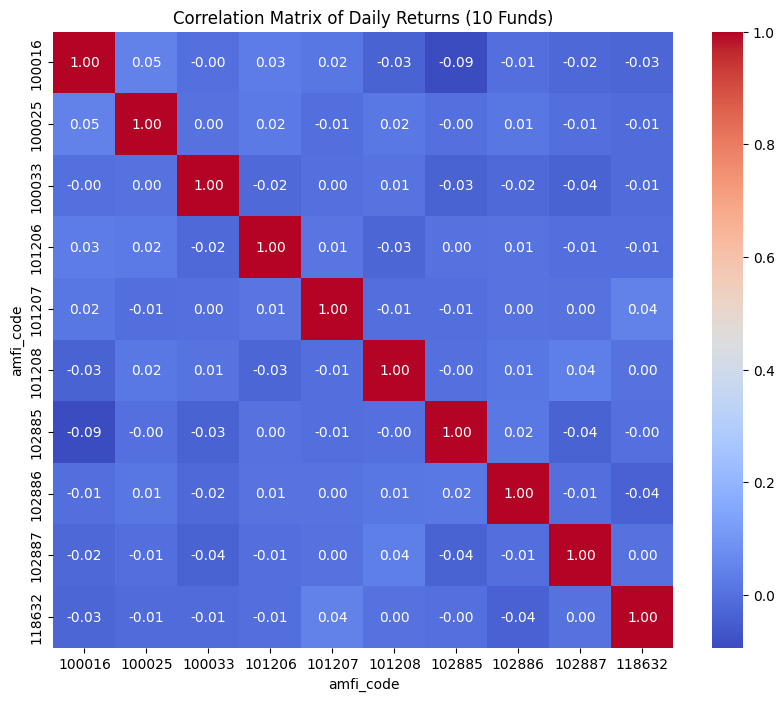

In [30]:
# heat map 


plt.figure(figsize=(10,8))

sns.heatmap(corr_matrix,annot=True,cmap="coolwarm",fmt=".2f")

plt.title("Correlation Matrix of Daily Returns (10 Funds)")

plt.show()

Most large-cap funds exhibit strong positive correlations in daily returns, indicating that they are influenced by similar market factors. Diversification benefits may therefore be limited among funds within the same category.

In [31]:
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [32]:
# Aggregate Sector Weights

sector_weights = (holdings.groupby("sector")["weight_pct"].sum().sort_values(ascending=False))
sector_weights

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64

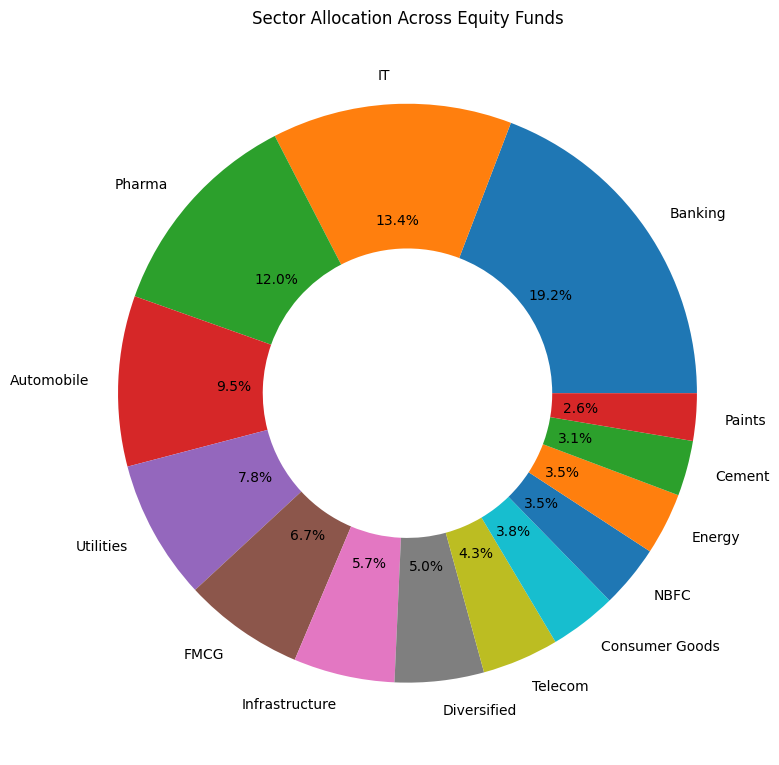

In [33]:


plt.figure(figsize=(8, 8))

plt.pie(
    sector_weights.values,
    labels=sector_weights.index,
    autopct='%1.1f%%',
    wedgeprops={'width': 0.5}  # Creates donut hole
)

plt.title("Sector Allocation Across Equity Funds")

plt.tight_layout()
plt.show()


Financial Services and Information Technology constitute the largest sector allocations across equity mutual funds, indicating a strong concentration in sectors that drive Indian equity market performance.

# Insight 1
Daily NAV trends showed a strong upward movement during the year 2023 , while several schemes experienced temporary corrections during 2024.
Reference: NAV Trend Analysis Chart

# Insight 2
SBI Mutual Fund maintained the highest AUM among fund houses, maintaining its dominant position in the mutual fund industry.
Reference: AUM Growth Bar Chart

# Insight 3
Monthly SIP inflows increased consistently from 2022 to 2025, reaching an all-time high of ₹31,002 crore in December 2025.
Reference: SIP Inflow Time-Series Chart

# Insight 4
Large Cap and Flexi Cap categories attracted higher net inflows compared to several other fund categories.
Reference: Category Inflow Heatmap

# Insight 5
The 26–35 age group represented the largest share of mutual fund investors, indicating strong participation from young professionals.
Reference: Age Group Distribution Pie Chart

# Insight 6
Higher age groups peoples generally invested larger SIP amounts, as indicated by the wider upper quartiles in the box plot.
Reference:SIP Amount by Age Group Box Plot

# Insight 7
Male investors are the majority of investors in the dataset, though female participation remains significant.
Reference: Gender Split Chart

# Insight 8
T30 cities contributed the majority of mutual fund investments, accounting for approximately 63% of investors.
Reference: T30 vs B30 Pie Chart

# Insight 9
Industry folio counts nearly doubled from 13.26 crore in January 2022 to 26.12 crore in December 2025, indicating rapid expansion of retail participation.
Reference: Folio Count Growth Line Chart

# Insight 10
Most equity-related funds exhibited strong positive correlations in daily returns, suggesting exposure to similar market drivers.
Reference: NAV Return Correlation Heatmap